In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

# Store Item Demand Forecasting — Time Series Project

**Author:** Zakee Ul Hassan
**Dataset:** [Kaggle: Store Item Demand Forecasting](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data) — 913K rows of daily sales
**Goal:** Forecast next 3 months of daily sales across 50 items × 10 stores. Compare baseline, classical (ARIMA/SARIMA), and ML approaches with walk-forward validation.

In [2]:
df = pd.read_csv('../data/train.csv')
print("Shape:",df.shape)
df.head()


Shape: (913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
df['date'] = pd.to_datetime(df['date'])
print("Date column dtype:", df['date'].dtype)
print("Date range:", df['date'].min(), "→", df['date'].max())

Date column dtype: datetime64[ns]
Date range: 2013-01-01 00:00:00 → 2017-12-31 00:00:00


In [4]:
print("Total rows:", len(df))
print("Total days:", (df['date'].max() - df['date'].min()).days + 1)
print("Unique stores:", df['store'].nunique())
print("Unique items:", df['item'].nunique())
print("Total combinations:", df['store'].nunique() * df['item'].nunique())
print("Rows per store-item:", len(df) / (df['store'].nunique() * df['item'].nunique()))

Total rows: 913000
Total days: 1826
Unique stores: 10
Unique items: 50
Total combinations: 500
Rows per store-item: 1826.0


In [5]:
print("Sales summary statistics:")
print(df['sales'].describe())
print("\nMissing values:")
print(df.isnull().sum())

Sales summary statistics:
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64


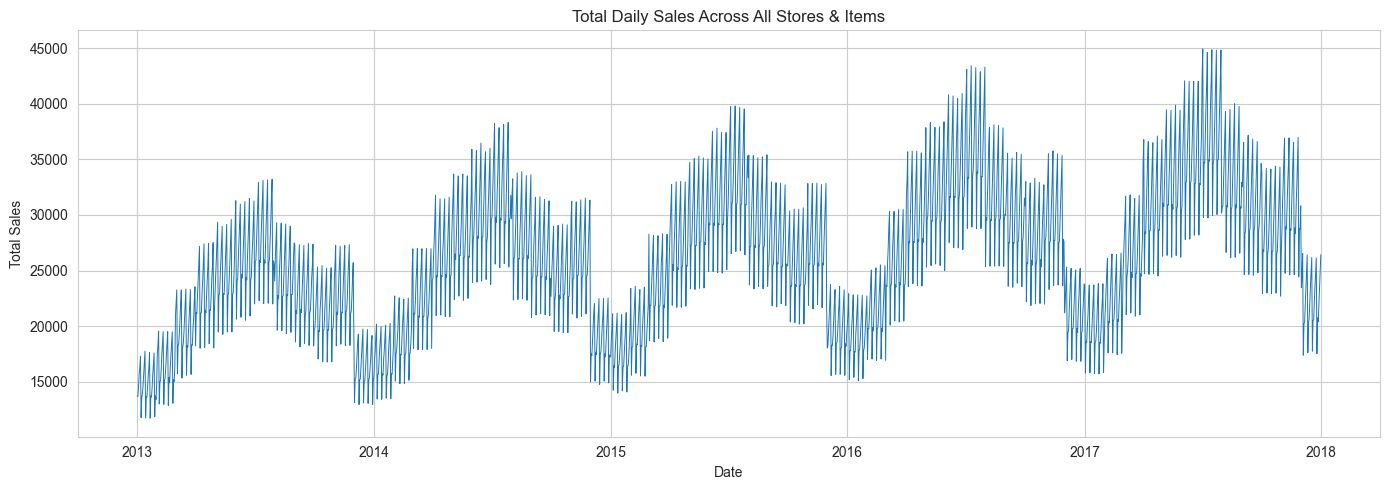

In [6]:
daily_total = df.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_total['date'], daily_total['sales'], linewidth=0.7)
plt.title('Total Daily Sales Across All Stores & Items')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('../total_daily_sales.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
daily_total.head()

,date,sales
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237


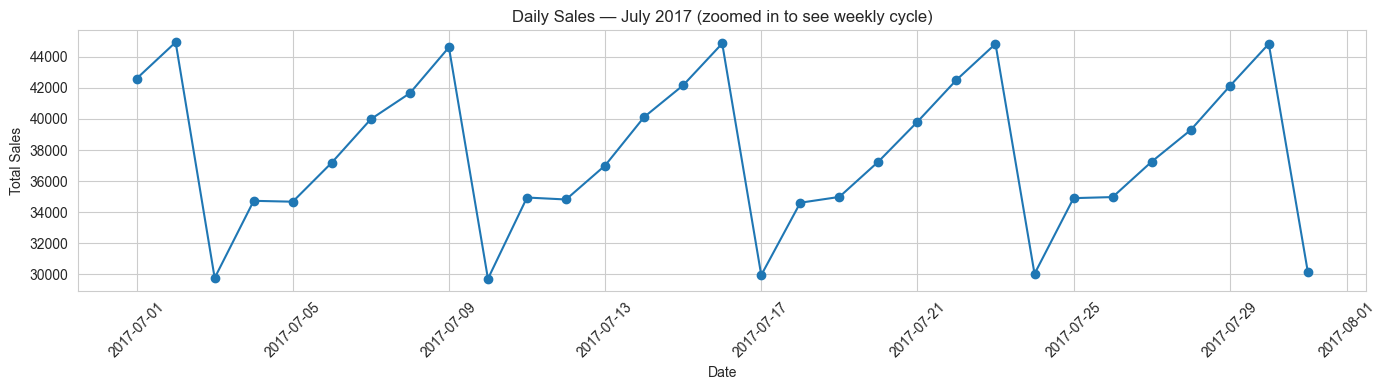

In [8]:
# Zoom in on one month to see weekly pattern
sample_month = daily_total[(daily_total['date'] >= '2017-07-01') & (daily_total['date'] <= '2017-07-31')]

plt.figure(figsize=(14, 4))
plt.plot(sample_month['date'], sample_month['sales'], marker='o', linewidth=1.5)
plt.title('Daily Sales — July 2017 (zoomed in to see weekly cycle)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../weekly_cycle.png', dpi=100, bbox_inches='tight')
plt.show()

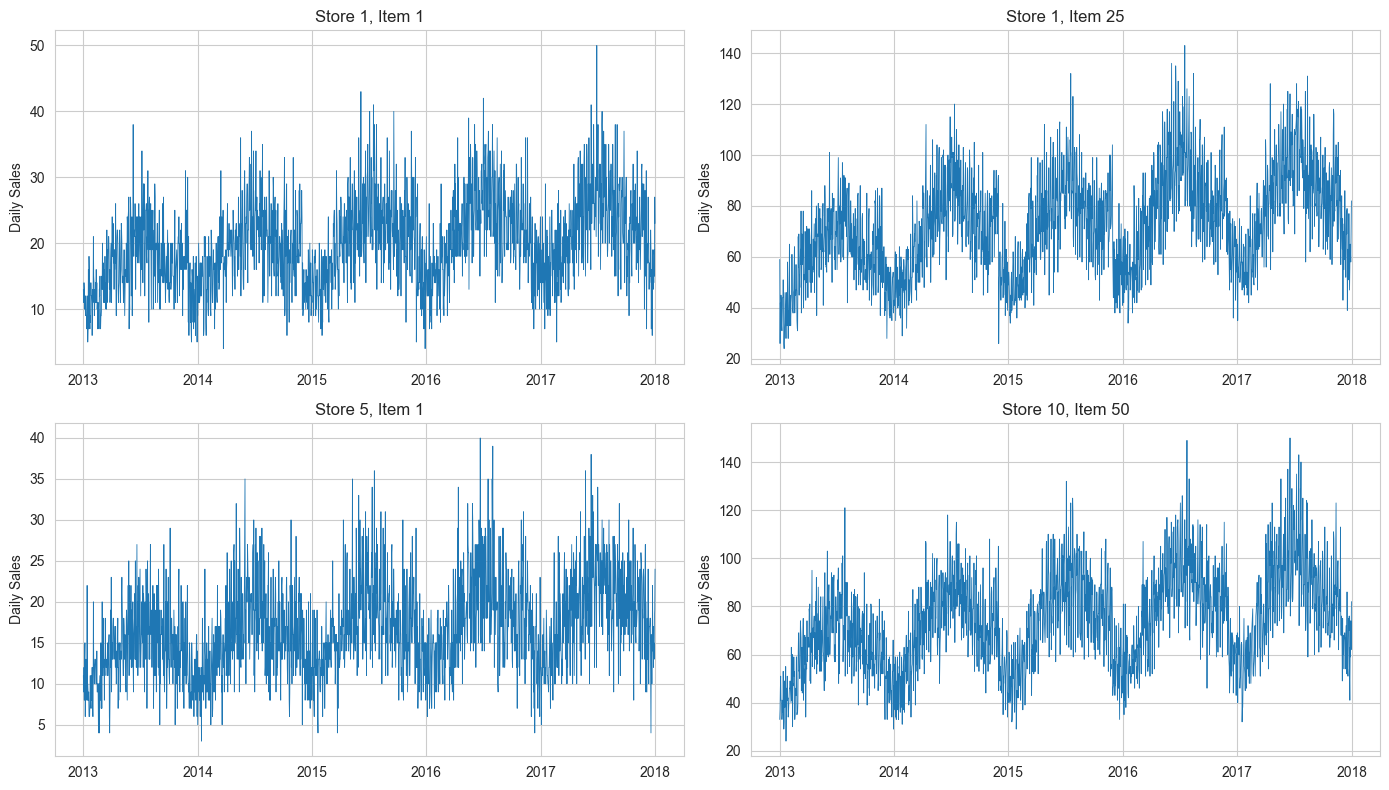

In [9]:
# Pick a few store-item combos to inspect individually
sample_combos = [
    (1, 1),    # store 1, item 1
    (1, 25),   # store 1, item 25 (mid-catalog)
    (5, 1),    # store 5, item 1 (different store, same item as first)
    (10, 50),  # store 10, item 50 (last store, last item)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (store, item) in enumerate(sample_combos):
    series = df[(df['store'] == store) & (df['item'] == item)]
    axes[i].plot(series['date'], series['sales'], linewidth=0.6)
    axes[i].set_title(f'Store {store}, Item {item}')
    axes[i].set_ylabel('Daily Sales')
    
plt.tight_layout()
plt.savefig('../sample_time_series.png', dpi=100, bbox_inches='tight')
plt.show()

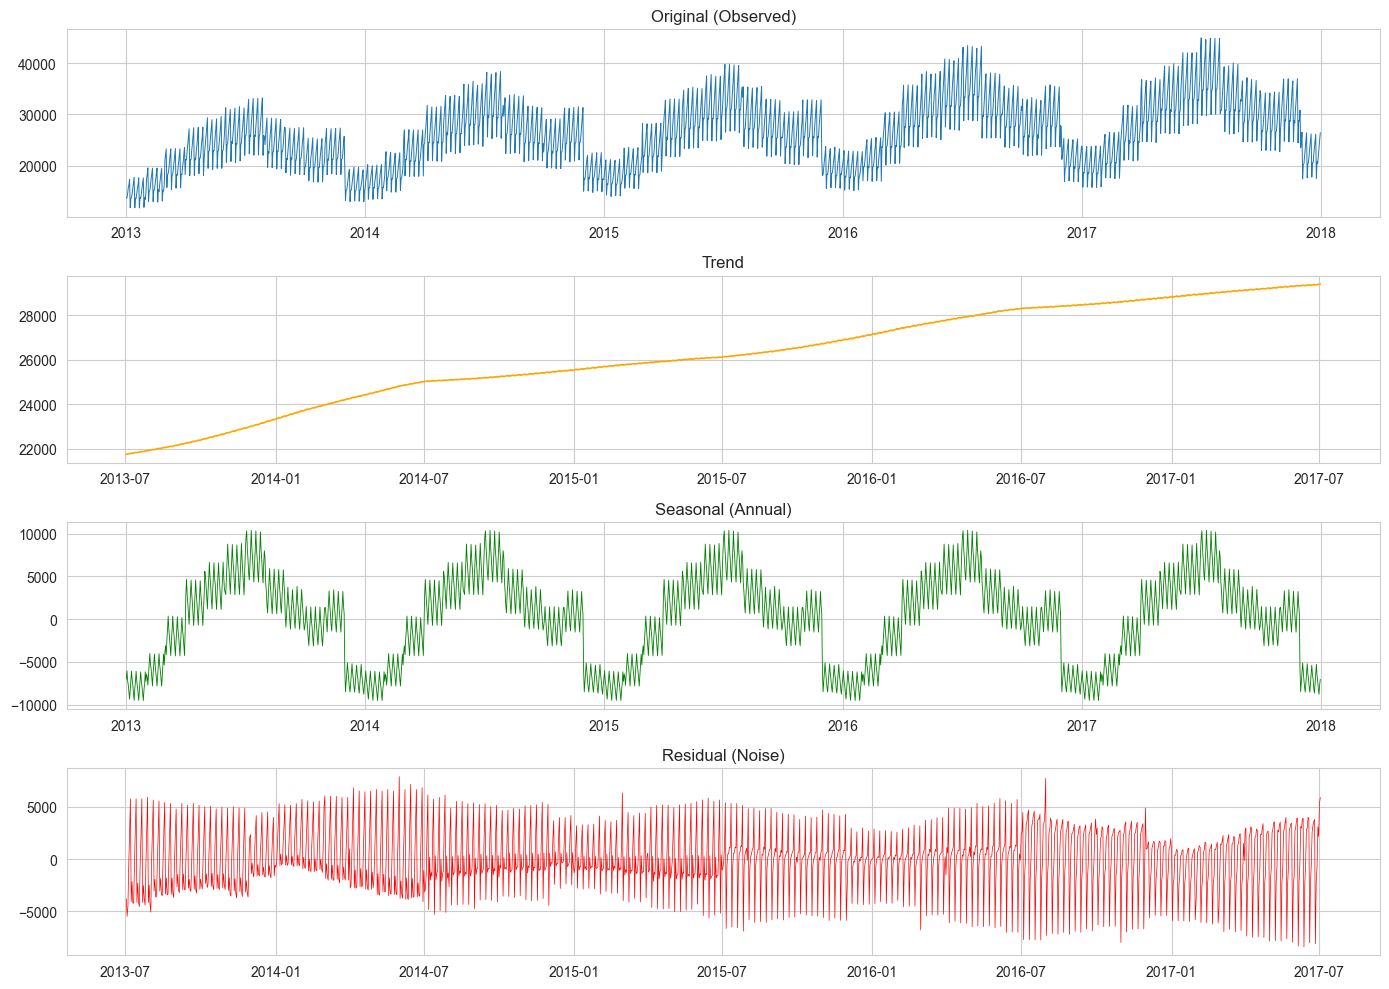

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# We need a clean time series with date as the index
ts = daily_total.set_index('date')['sales']

# Decompose with annual seasonality (period=365 days)
decomp = seasonal_decompose(ts, model='additive', period=365)

# Plot all 4 components: original, trend, seasonal, residual
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(decomp.observed, linewidth=0.7)
axes[0].set_title('Original (Observed)')

axes[1].plot(decomp.trend, color='orange', linewidth=1.2)
axes[1].set_title('Trend')

axes[2].plot(decomp.seasonal, color='green', linewidth=0.6)
axes[2].set_title('Seasonal (Annual)')

axes[3].plot(decomp.resid, color='red', linewidth=0.5)
axes[3].set_title('Residual (Noise)')

plt.tight_layout()
plt.savefig('../decomposition.png', dpi=100, bbox_inches='tight')
plt.show()

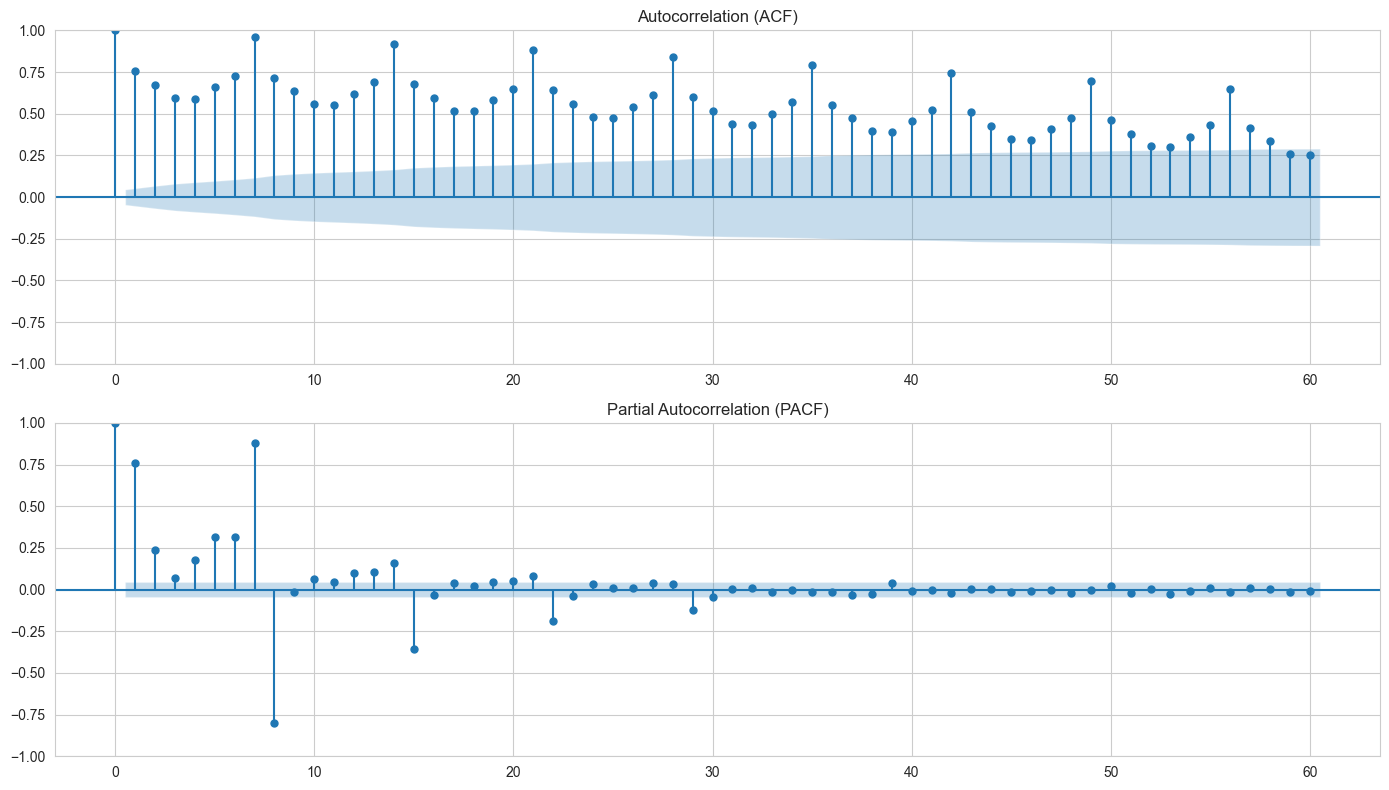

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# We'll plot ACF and PACF on the original total daily sales
# Lags up to 60 days — enough to see daily, weekly, and ~monthly patterns
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts, lags=60, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

plot_pacf(ts, lags=60, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.savefig('../acf_pacf.png', dpi=100, bbox_inches='tight')
plt.show()

### Initial Observations

- **Dataset:** 913,000 rows = 10 stores × 50 items × 1,826 days (5 years, 2013-2017). 500 distinct time series in total.
- **No missing values, no data quality issues** — clean dataset, can move directly to modeling pipeline.
- **Sales statistics:** range 0 to 231, mean ~52, integer-valued count data. Same family as my thesis target (mortality counts) — Poisson-like models will be appropriate.
- **Strong upward trend over 5 years** — sales are growing year-over-year; will need to handle non-stationarity before applying ARIMA.
- **Annual seasonality** with clear summer peaks (June-August). Suggests SARIMA with seasonal_period=365 or seasonal feature engineering.
- **Weekly cycle** visible in zoomed view — weekend peaks, weekday troughs. Will need to capture day-of-week in features for ML models.
- **Sample series are similar in shape, different in scale.** Inspected 4 store-item combos. All show same trend + seasonality + weekly pattern but at different magnitudes (peaks ~40 to ~140). This means a single model architecture should generalize across all 500 series — we won't need clustering or per-segment models.
- **Decomposition confirms 3 components:** clear upward trend, clean repeating annual seasonality, and residual showing weekly cycle (which annual decomposition didn't capture). Total demand has multi-scale seasonality — annual + weekly — both will need to be modeled.
- **ACF/PACF analysis confirms weekly seasonality (period=7).** PACF shows strong direct effects from lags 1-7 with a sharp cutoff at lag 8, indicating the weekly cycle dominates short-term prediction. ACF shows recurring spikes at lags 7, 14, 21, 28 — multi-week structure consistent with the residual pattern from decomposition.
- **Modeling implications:** The weekly cycle is the single strongest predictable signal. SARIMA with seasonal period=7 is a strong baseline candidate. For ML approaches (Random Forest, XGBoost), engineered lag features should include lag_1, lag_7, lag_14 at minimum, plus rolling statistics (7-day and 30-day means).

In [12]:
from statsmodels.tsa.stattools import adfuller, kpss

# Run ADF test on the original total daily sales
adf_result = adfuller(ts.dropna())
print("=== ADF Test (Augmented Dickey-Fuller) ===")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Verdict:       {'STATIONARY' if adf_result[1] < 0.05 else 'NON-STATIONARY'}")
print()

# Run KPSS test
kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')
print("=== KPSS Test ===")
print(f"KPSS Statistic: {kpss_result[0]:.4f}")
print(f"p-value:        {kpss_result[1]:.4f}")
print(f"Verdict:        {'STATIONARY' if kpss_result[1] > 0.05 else 'NON-STATIONARY'}")

=== ADF Test (Augmented Dickey-Fuller) ===
ADF Statistic: -3.0602
p-value:       0.0296
Verdict:       STATIONARY

=== KPSS Test ===
KPSS Statistic: 2.0010
p-value:        0.0100
Verdict:        NON-STATIONARY


C:\Users\NEXGEN\AppData\Local\Temp\ipykernel_15484\4062342713.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')


**Stationarity tests confirm non-stationarity.**  ADF (p < 0.05, rejects non-stationary null) and KPSS (p < 0.05, reject stationary null) agree the original series has a trend. ARIMA will need d=1 (one differencing step) to convert to stationary input.

In [13]:
# Split chronologically: train on 2013-2016, test on 2017
train = ts[ts.index < '2017-01-01']
test = ts[ts.index >= '2017-01-01']

print(f"Train: {len(train)} days, from {train.index.min().date()} to {train.index.max().date()}")
print(f"Test:  {len(test)} days, from {test.index.min().date()} to {test.index.max().date()}")

Train: 1461 days, from 2013-01-01 to 2016-12-31
Test:  365 days, from 2017-01-01 to 2017-12-31


Last training day value: 23792


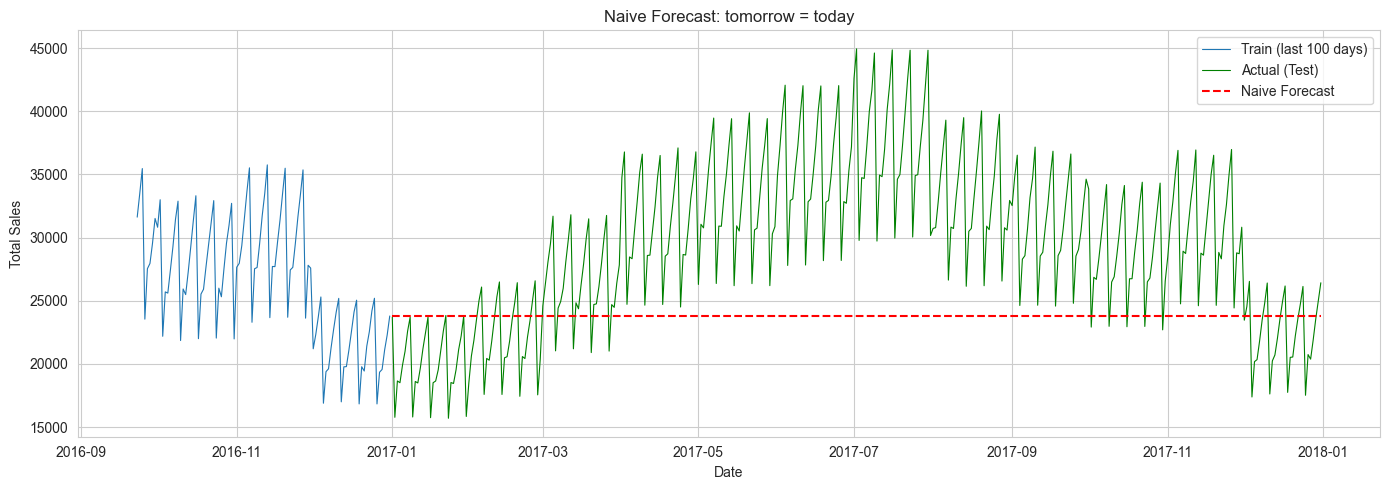

In [14]:
# The single value used for all naive predictions
naive_value = train.iloc[-1]
print(f"Last training day value: {naive_value}")

# Naive forecast: that value repeated for every test day
naive_forecast = pd.Series(
    [naive_value] * len(test),
    index=test.index
)

# Plot it
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(naive_forecast.index, naive_forecast.values, label='Naive Forecast', linewidth=1.5, color='red', linestyle='--')
plt.title('Naive Forecast: tomorrow = today')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../naive_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

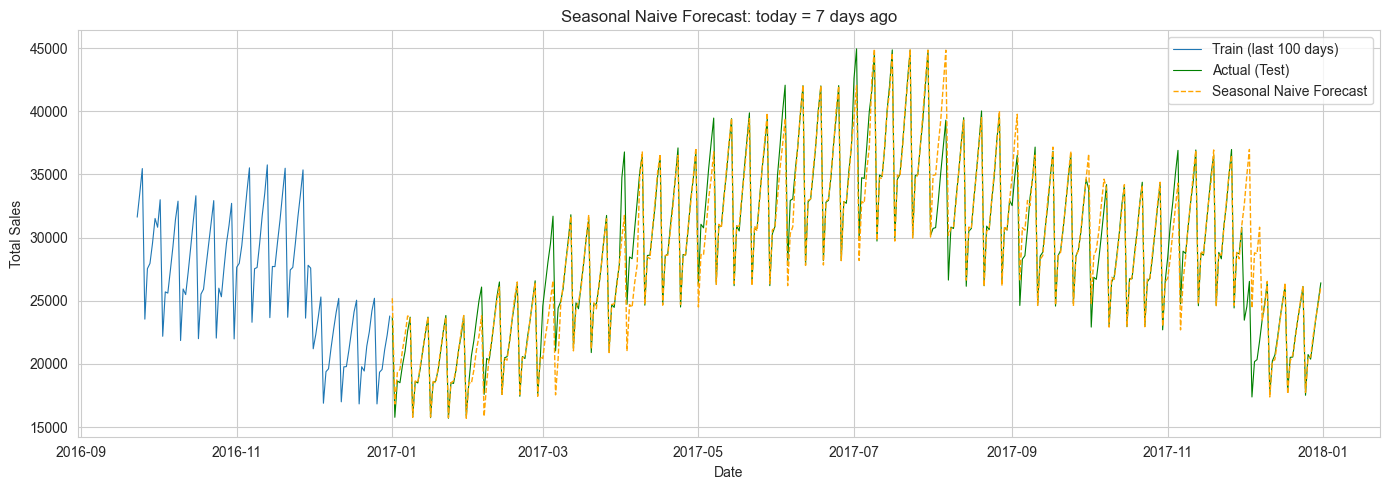

In [15]:
# For each test day, use the value from 7 days earlier
# We need the last 7 training days as the "lookup" for the first week of test
seasonal_naive_forecast = pd.Series(index=test.index, dtype=float)

for i, date in enumerate(test.index):
    # Look back 7 days in the combined train+test history
    lookup_date = date - pd.Timedelta(days=7)
    if lookup_date in train.index:
        seasonal_naive_forecast.iloc[i] = train.loc[lookup_date]
    elif lookup_date in test.index:
        # Use the previously-known test value (from a week ago)
        seasonal_naive_forecast.iloc[i] = test.loc[lookup_date]

# Plot it
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(seasonal_naive_forecast.index, seasonal_naive_forecast.values, 
         label='Seasonal Naive Forecast', linewidth=1.0, color='orange', linestyle='--')
plt.title('Seasonal Naive Forecast: today = 7 days ago')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../seasonal_naive_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
ts_diff = ts.diff().dropna()

In [22]:
result = adfuller(ts_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

result = kpss(ts_diff, regression='c')  # 'c' = constant

print("KPSS Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -8.919026559804896
p-value: 1.0533756813425918e-14
KPSS Statistic: 0.051142568728619525
p-value: 0.1


C:\Users\NEXGEN\AppData\Local\Temp\ipykernel_22080\73074541.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(ts_diff, regression='c')  # 'c' = constant


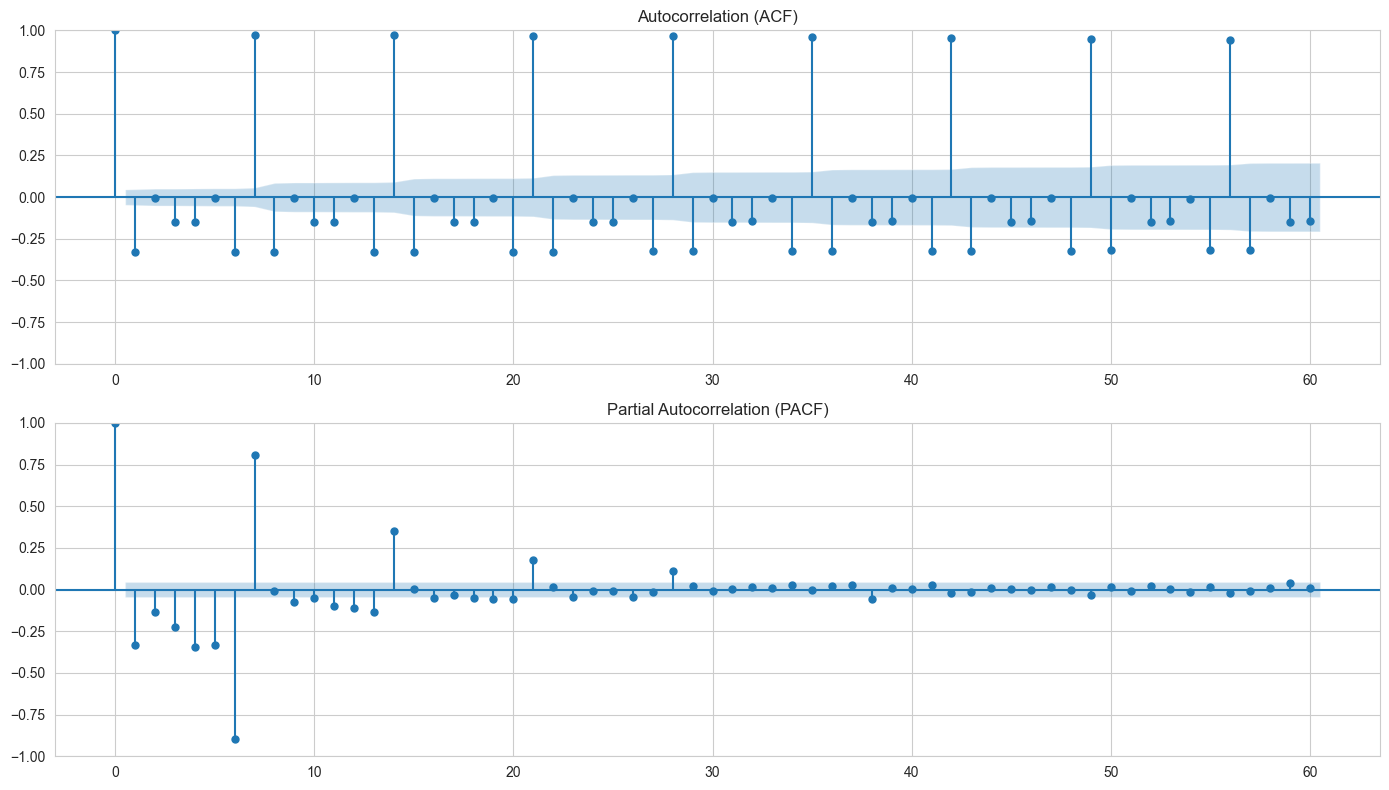

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts_diff, lags=60, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

plot_pacf(ts_diff, lags=60, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

In [34]:
ts = ts.sort_index()

split_point = int(len(ts) * 0.8)

train = ts.iloc[:split_point]
test = ts.iloc[split_point:]

In [35]:
naive_forecast = test.copy()
naive_forecast[:] = train.iloc[-1]

In [36]:
seasonal_forecast = ts.shift(7).iloc[split_point:]

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [38]:
# align properly (drop NaNs)
naive_forecast = naive_forecast.dropna()
seasonal_forecast = seasonal_forecast.dropna()
test_aligned = test.loc[naive_forecast.index]

# Naive
mae_naive, rmse_naive = evaluate(test_aligned, naive_forecast)

# Seasonal naive
mae_seasonal, rmse_seasonal = evaluate(test_aligned, seasonal_forecast)

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

print("Seasonal MAE:", mae_seasonal)
print("Seasonal RMSE:", rmse_seasonal)

Naive MAE: 7953.879781420765
Naive RMSE: 9625.05082067344
Seasonal MAE: 901.1748633879781
Seasonal RMSE: 1865.973829755748


In [39]:
results = []

In [ ]:
results.append(["Naive", mae_naive, rmse_naive])
results.append(["Seasonal Naive", mae_seasonal, rmse_seasonal])

In [41]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE"])
print(results_df)

            Model          MAE         RMSE
0           Naive  7953.879781  9625.050821
1  Seasonal Naive   901.174863  1865.973830


In [42]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [53]:
arima_model = ARIMA(train, order=(5,1,4))  # from your AIC result
arima_fit = arima_model.fit()

c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [54]:
arima_forecast = arima_fit.forecast(steps=len(test))

In [55]:
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 9248.024655187628
ARIMA RMSE: 10974.845035491739


In [56]:
aic_arima = arima_fit.aic
print("ARIMA AIC:", aic_arima)

ARIMA AIC: 27117.81237741401


In [57]:
sarima_model = SARIMAX(
    train,
    order=(4,1,0),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [49]:
sarima_forecast = sarima_fit.forecast(steps=len(test))

In [50]:
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)

SARIMA MAE: 24463.63716047609
SARIMA RMSE: 27198.173124725632


In [51]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "MAE": [arima_mae, sarima_mae],
    "RMSE": [arima_rmse, sarima_rmse]
})

print(results)

    Model           MAE          RMSE
0   ARIMA   9236.197335  10978.208617
1  SARIMA  24463.637160  27198.173125


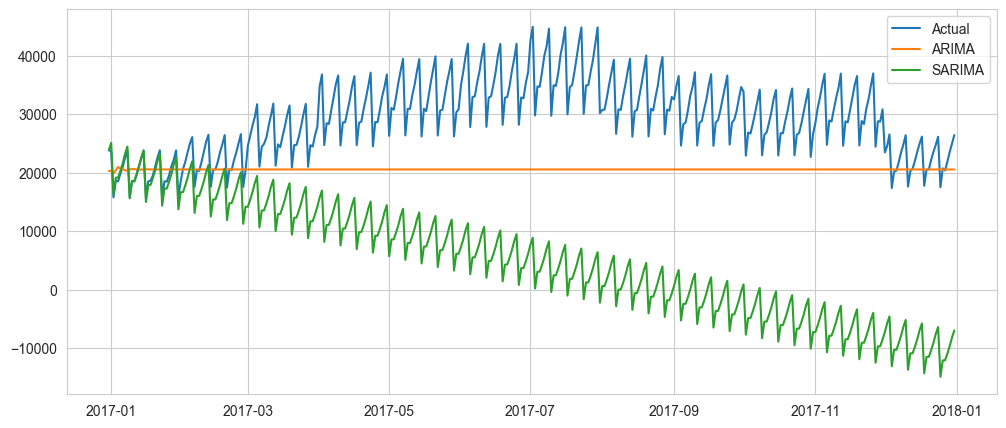

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, arima_forecast, label="ARIMA")
plt.plot(test.index, sarima_forecast, label="SARIMA")
plt.legend()
plt.show()

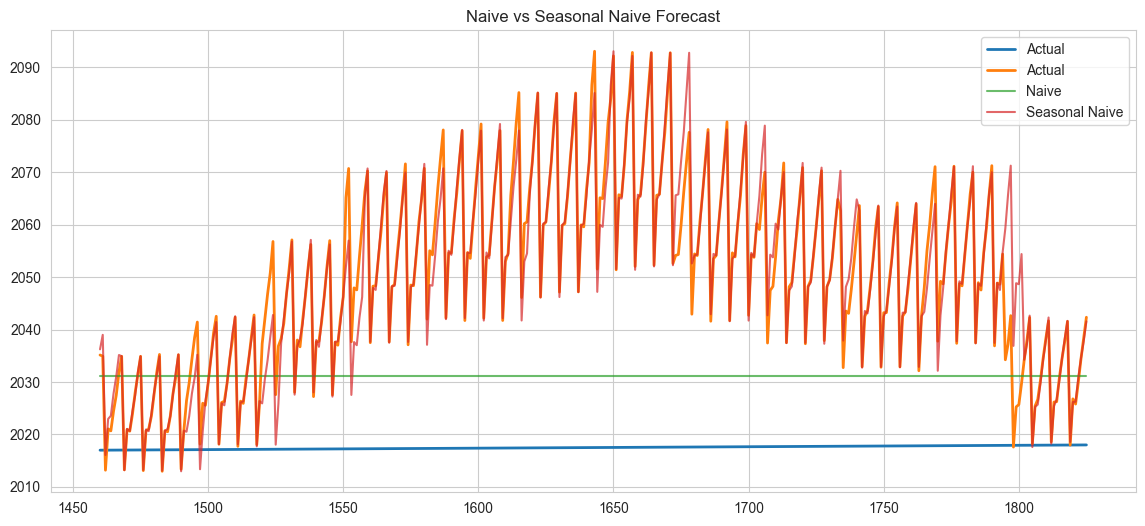

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(test.index, test.values, label="Actual", linewidth=2)
plt.plot(test.index, naive_forecast.values, label="Naive", alpha=0.7)
plt.plot(test.index, seasonal_forecast.values, label="Seasonal Naive", alpha=0.7)

plt.title("Naive vs Seasonal Naive Forecast")
plt.legend()
plt.show()

In [59]:
df = pd.DataFrame({
    "ds": ts.index,
    "y": ts.values
})

In [61]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

In [62]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

Importing plotly failed. Interactive plots will not work.
18:30:37 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1] done processing


In [63]:
future = model.make_future_dataframe(periods=len(test), freq='D')
forecast = model.predict(future)

In [64]:
pred = forecast.iloc[-len(test):]["yhat"]

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["y"], pred)
rmse = np.sqrt(mean_squared_error(test["y"], pred))

print("Prophet MAE:", mae)
print("Prophet RMSE:", rmse)

Prophet MAE: 1486.768632612507
Prophet RMSE: 1776.3168287770159


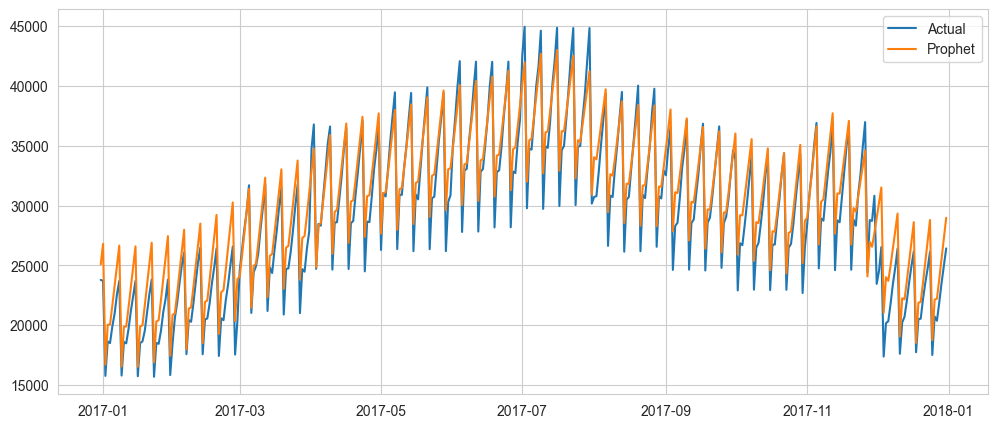

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test["ds"], test["y"], label="Actual")
plt.plot(test["ds"], pred.values, label="Prophet")
plt.legend()
plt.show()

In [68]:
df = pd.DataFrame(ts)
df.columns = ["y"]

df["lag1"] = df["y"].shift(1)
df["lag7"] = df["y"].shift(7)
df["rolling7"] = df["y"].rolling(7).mean()

df = df.dropna()

In [69]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

X_train = train.drop("y", axis=1)
y_train = train["y"]

X_test = test.drop("y", axis=1)
y_test = test["y"]

In [72]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [73]:
pred = model.predict(X_test)

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("XGBoost MAE:", mae)
print("XGBoost RMSE:", rmse)

XGBoost MAE: 858.4419555664062
XGBoost RMSE: 1297.41796465133


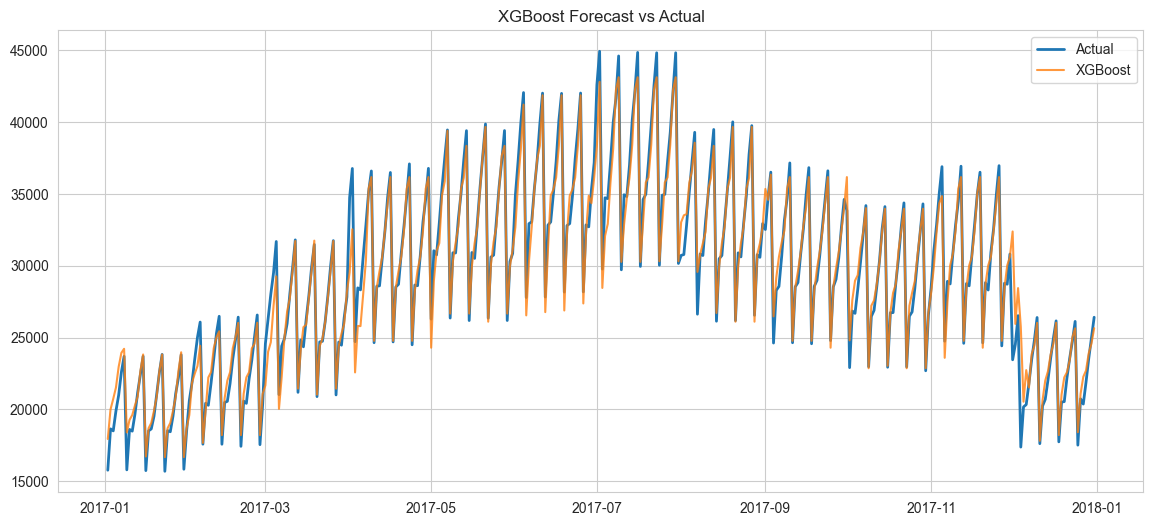

In [75]:
plt.figure(figsize=(14,6))

plt.plot(y_test.index, y_test.values, label="Actual", linewidth=2)
plt.plot(y_test.index, pred, label="XGBoost", alpha=0.8)

plt.title("XGBoost Forecast vs Actual")
plt.legend()
plt.show()

In [76]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [77]:
rf_pred = rf_model.predict(X_test)

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 802.6449493999846
Random Forest RMSE: 1265.477194905271


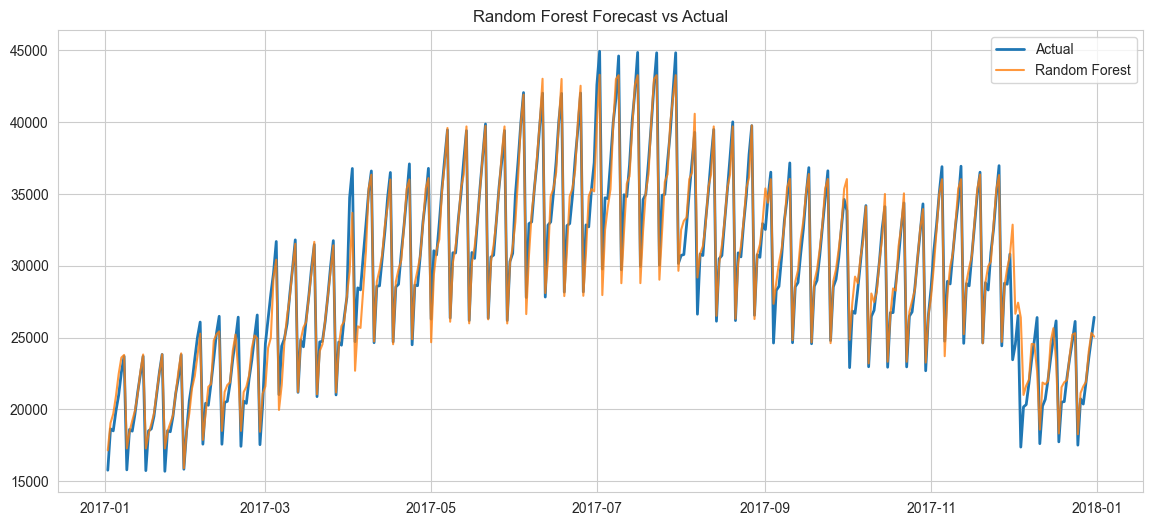

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(y_test.index, y_test.values, label="Actual", linewidth=2)
plt.plot(y_test.index, rf_pred, label="Random Forest", alpha=0.8)

plt.title("Random Forest Forecast vs Actual")
plt.legend()
plt.show()

In [88]:
seasonal_pred = ts.shift(7)
seasonal_pred = seasonal_pred.dropna()

actual = ts.loc[seasonal_pred.index]

In [89]:

y_test_aligned = ts.iloc[split:]

In [98]:
residuals = y_test_aligned - seasonal_pred

In [105]:
df = pd.DataFrame(ts)
df.columns = ["y"]

df["lag1"] = df["y"].shift(1)
df["lag7"] = df["y"].shift(7)
df["rolling7"] = df["y"].rolling(7).mean()

df = df.dropna()


In [106]:
split = int(len(df)*0.8)

train = df.iloc[:split]
test = df.iloc[split:]

In [107]:
X_train = train[["lag1","lag7","rolling7"]]
y_train = train["y"]

X_test = test[["lag1","lag7","rolling7"]]
y_test = test["y"]

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [108]:
seasonal = test["y"].shift(7)

In [109]:
residual_pred = rf.predict(X_test)


final_pred = seasonal.values + residual_pred

In [110]:
valid_idx = ~np.isnan(seasonal.values)

final_pred = final_pred[valid_idx]
actual = y_test.values[valid_idx]

In [111]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, final_pred)
rmse = np.sqrt(mean_squared_error(actual, final_pred))

print("Hybrid MAE:", mae)
print("Hybrid RMSE:", rmse)

Hybrid MAE: 29598.864565826327
Hybrid RMSE: 30302.118708075595


In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(actual.index, actual.values, label="Actual", linewidth=2)
plt.plot(actual.index, final_pred, label="Hybrid", alpha=0.8)

plt.legend()
plt.title("Hybrid Model (Seasonal + Random Forest Residuals)")
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'index'

<Figure size 1400x600 with 0 Axes>